In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scienceplots
import pickle
from tqdm import tqdm
plt.style.use(['science','no-latex'])
colors = ["#1982c4", "black", "#ff595e", "#20b806"]

# THREE MINIMA WITH Z (NONINFO)

### 1) Transfer entropy

In [2]:
k = 7
N = 2500
taus = np.concatenate(([1],np.arange(5,5+25*5,25,dtype=int), np.arange(105,900-1,40,dtype=int))) * 10
#taus = np.arange(10,4810+100,200,dtype=int) * 10
print(taus.shape)
seeds = np.arange(20)

(26,)


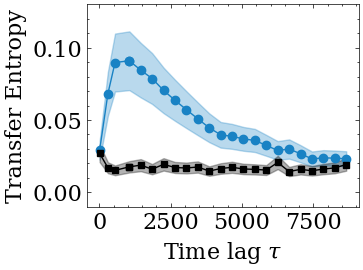

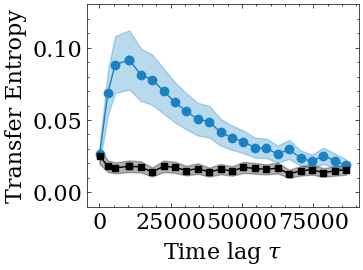

In [12]:
taus = np.concatenate(([1],np.arange(5,5+25*5,25,dtype=int), np.arange(105,900-1,40,dtype=int))) * 10

plt.rcParams.update({'font.size': 16})

TEs_X_to_Y = np.zeros((len(seeds),len(taus)))
TEs_Y_to_X = np.zeros((len(seeds),len(taus)))
TEs_X_to_Y_givenZ = np.zeros((len(seeds),len(taus)))
TEs_Y_to_X_givenZ = np.zeros((len(seeds),len(taus)))

for iseed, seed in enumerate(seeds):
    _, TEs_X_to_Y[iseed], TEs_Y_to_X[iseed], TEs_X_to_Y_givenZ[iseed], TEs_Y_to_X_givenZ[iseed] = (
        pickle.load(open(f"/scratch/vdeltatt/imbalance-gain-causality/langevin/three_minima_with_z_noninfo/pickles_te/seed{seed}_N{N}_k{k}.p","rb"))
    )

itau_rm = [1,4]

# bivariate
avg_X_to_Y, err_X_to_Y = TEs_X_to_Y.mean(axis=0), TEs_X_to_Y.mean(axis=0) / np.sqrt(TEs_X_to_Y.shape[0])
avg_Y_to_X, err_Y_to_X = TEs_Y_to_X.mean(axis=0), TEs_Y_to_X.mean(axis=0) / np.sqrt(TEs_Y_to_X.shape[0])

taus = np.delete(taus, itau_rm)
avg_X_to_Y = np.delete(avg_X_to_Y, itau_rm)
avg_Y_to_X = np.delete(avg_Y_to_X, itau_rm)
err_X_to_Y = np.delete(err_X_to_Y, itau_rm)
err_Y_to_X = np.delete(err_Y_to_X, itau_rm)

plt.plot(taus, avg_X_to_Y, 'o-', color=colors[0])
plt.plot(taus, avg_Y_to_X, 's-', color=colors[1], markersize=5)
plt.fill_between(taus, avg_X_to_Y-err_X_to_Y, avg_X_to_Y+err_X_to_Y, alpha=0.3, color=colors[0])
plt.fill_between(taus, avg_Y_to_X-err_Y_to_X, avg_Y_to_X+err_Y_to_X, alpha=0.3, color=colors[1])
#plt.hlines(0.0, taus[0], taus[-1], linestyle="--", color="black")
plt.xlabel("Time lag $\\tau$")
plt.ylabel("Transfer Entropy")
plt.ylim([-0.01, 0.13])
#plt.legend()
plt.savefig('/scratch/vdeltatt/imbalance-gain-causality/langevin/three_minima_with_z_noninfo/figures/TE_3minima_withZ_cont.pdf', transparent=True, dpi=300)
plt.show()

# conditioning
avg_X_to_Y, err_X_to_Y = TEs_X_to_Y_givenZ.mean(axis=0), TEs_X_to_Y_givenZ.mean(axis=0) / np.sqrt(TEs_X_to_Y_givenZ.shape[0])
avg_Y_to_X, err_Y_to_X = TEs_Y_to_X_givenZ.mean(axis=0), TEs_Y_to_X_givenZ.mean(axis=0) / np.sqrt(TEs_Y_to_X_givenZ.shape[0])

avg_X_to_Y = np.delete(avg_X_to_Y, itau_rm)
avg_Y_to_X = np.delete(avg_Y_to_X, itau_rm)
err_X_to_Y = np.delete(err_X_to_Y, itau_rm)
err_Y_to_X = np.delete(err_Y_to_X, itau_rm)

plt.plot(10*taus, avg_X_to_Y, 'o-', color=colors[0])
plt.plot(10*taus, avg_Y_to_X, 's-', color=colors[1], markersize=5)
plt.fill_between(10*taus, avg_X_to_Y-err_X_to_Y, avg_X_to_Y+err_X_to_Y, alpha=0.3, color=colors[0])
plt.fill_between(10*taus, avg_Y_to_X-err_Y_to_X, avg_Y_to_X+err_Y_to_X, alpha=0.3, color=colors[1])
#plt.hlines(0.0, taus[0], taus[-1], linestyle="--", color="black")
plt.xlabel("Time lag $\\tau$")
plt.ylabel("Transfer Entropy")
plt.ylim([-0.01, 0.13])
#plt.legend()
plt.savefig('/scratch/vdeltatt/imbalance-gain-causality/langevin/three_minima_with_z_noninfo/figures/TE_3minima_withZ_cont_conditional_on_Z.pdf', transparent=True, dpi=300)
plt.show()

Only bivariate (noZ), no markers

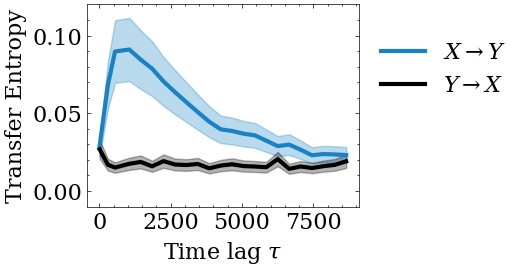

In [11]:
taus = np.concatenate(([1],np.arange(5,5+25*5,25,dtype=int), np.arange(105,900-1,40,dtype=int))) * 10

plt.rcParams.update({'font.size': 16})

TEs_X_to_Y = np.zeros((len(seeds),len(taus)))
TEs_Y_to_X = np.zeros((len(seeds),len(taus)))
TEs_X_to_Y_givenZ = np.zeros((len(seeds),len(taus)))
TEs_Y_to_X_givenZ = np.zeros((len(seeds),len(taus)))

for iseed, seed in enumerate(seeds):
    _, TEs_X_to_Y[iseed], TEs_Y_to_X[iseed], TEs_X_to_Y_givenZ[iseed], TEs_Y_to_X_givenZ[iseed] = (
        pickle.load(open(f"/scratch/vdeltatt/imbalance-gain-causality/langevin/three_minima_with_z_noninfo/pickles_te/seed{seed}_N{N}_k{k}.p","rb"))
    )

# bivariate
avg_X_to_Y, err_X_to_Y = TEs_X_to_Y.mean(axis=0), TEs_X_to_Y.mean(axis=0) / np.sqrt(TEs_X_to_Y.shape[0])
avg_Y_to_X, err_Y_to_X = TEs_Y_to_X.mean(axis=0), TEs_Y_to_X.mean(axis=0) / np.sqrt(TEs_Y_to_X.shape[0])

itau_rm = [1,4]
taus = np.delete(taus, itau_rm)
avg_X_to_Y = np.delete(avg_X_to_Y, itau_rm)
avg_Y_to_X = np.delete(avg_Y_to_X, itau_rm)
err_X_to_Y = np.delete(err_X_to_Y, itau_rm)
err_Y_to_X = np.delete(err_Y_to_X, itau_rm)

plt.plot(taus, avg_X_to_Y, '-', color=colors[0], linewidth=3, label="$X\\rightarrow Y$")
plt.plot(taus, avg_Y_to_X, '-', color=colors[1], linewidth=3, label="$Y\\rightarrow X$")
plt.fill_between(taus, avg_X_to_Y-err_X_to_Y, avg_X_to_Y+err_X_to_Y, alpha=0.3, color=colors[0])
plt.fill_between(taus, avg_Y_to_X-err_Y_to_X, avg_Y_to_X+err_Y_to_X, alpha=0.3, color=colors[1])
#plt.hlines(0.0, taus[0], taus[-1], linestyle="--", color="black")
plt.xlabel("Time lag $\\tau$")
plt.ylabel("Transfer Entropy")
plt.ylim([-0.01, 0.12])
plt.legend(loc=(1.05,0.5))
plt.savefig('/scratch/vdeltatt/imbalance-gain-causality/langevin/three_minima_with_z_noninfo/figures/TE_3minima_withZ_cont_nomarkers.pdf', transparent=True, dpi=300)
plt.show()

### Version for presentation only
NB execute before running other blocks

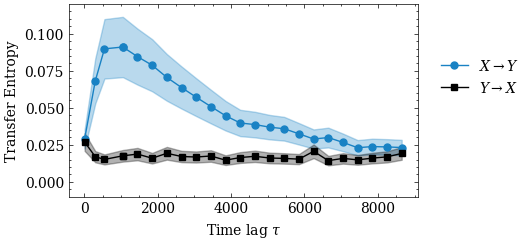

In [3]:
taus = np.concatenate(([1],np.arange(5,5+25*5,25,dtype=int), np.arange(105,900-1,40,dtype=int))) * 10

TEs_X_to_Y = np.zeros((len(seeds),len(taus)))
TEs_Y_to_X = np.zeros((len(seeds),len(taus)))
TEs_X_to_Y_givenZ = np.zeros((len(seeds),len(taus)))
TEs_Y_to_X_givenZ = np.zeros((len(seeds),len(taus)))

for iseed, seed in enumerate(seeds):
    _, TEs_X_to_Y[iseed], TEs_Y_to_X[iseed], TEs_X_to_Y_givenZ[iseed], TEs_Y_to_X_givenZ[iseed] = (
        pickle.load(open(f"/scratch/vdeltatt/imbalance-gain-causality/langevin/three_minima_with_z_noninfo/pickles_te/seed{seed}_N{N}_k{k}.p","rb"))
    )

# bivariate
avg_X_to_Y, err_X_to_Y = TEs_X_to_Y.mean(axis=0), TEs_X_to_Y.mean(axis=0) / np.sqrt(TEs_X_to_Y.shape[0])
avg_Y_to_X, err_Y_to_X = TEs_Y_to_X.mean(axis=0), TEs_Y_to_X.mean(axis=0) / np.sqrt(TEs_Y_to_X.shape[0])

itau_rm = [1,4]
taus = np.delete(taus, itau_rm)
avg_X_to_Y = np.delete(avg_X_to_Y, itau_rm)
avg_Y_to_X = np.delete(avg_Y_to_X, itau_rm)
err_X_to_Y = np.delete(err_X_to_Y, itau_rm)
err_Y_to_X = np.delete(err_Y_to_X, itau_rm)

fig, ax = plt.subplots(1,figsize=(4.5,2.5))

ax.plot(taus, avg_X_to_Y, 'o-', color=colors[0], linewidth=1, markersize=5, label="$X\\rightarrow Y$")
ax.plot(taus, avg_Y_to_X, 's-', color=colors[1], linewidth=1, markersize=4, label="$Y\\rightarrow X$")
ax.fill_between(taus, avg_X_to_Y-err_X_to_Y, avg_X_to_Y+err_X_to_Y, alpha=0.3, color=colors[0])
ax.fill_between(taus, avg_Y_to_X-err_Y_to_X, avg_Y_to_X+err_Y_to_X, alpha=0.3, color=colors[1])
#ax.hlines(0.0, taus[0], taus[-1], linestyle="--", color="black")
ax.set_xlabel("Time lag $\\tau$")
ax.set_ylabel("Transfer Entropy")
ax.set_ylim([-0.01, 0.12])
ax.legend(loc=(1.05,0.5))
plt.savefig('/scratch/vdeltatt/imbalance-gain-causality/langevin/three_minima_with_z_noninfo/figures/TE_3minima_withZ_cont_SLIDES.pdf', transparent=True, dpi=300)
plt.show()